<h1>Laboratorio Integrador</h1>

<p>Se trabaja con un modelo de aprendizaje automatico de caja negra y se aplican
dos tecnicas de explicabilidad estudiadas en clase. El dataset es el mismo de la
tesis de grado (VinDr-Mammo) y el modelo de caja negra es el clasificador
mamografico <code>exp08</code> del sistema MammoVLM V2.</p>

<h3>Objetivo</h3>
<ul>
  <li>Implementar dos modulos de explicabilidad sobre un modelo de caja negra.</li>
  <li>Analizar y contrastar los resultados obtenidos por cada tecnica.</li>
</ul>

<h3>Actividad evaluativa</h3>
<ol>
  <li>Trabajo individual.</li>
  <li>Transferir un modelo de aprendizaje automatico sobre el dataset de la tesis.</li>
  <li>Implementar dos tecnicas de explicabilidad sobre el modelo de caja negra del punto 2.</li>
  <li>Presentar un analisis de resultados de las tecnicas del punto 3.</li>
  <li>Escribir conclusiones propias sobre el experimento.</li>
  <li>Subir el cuaderno desarrollado a la carpeta de trabajo en el D2L.</li>
</ol>



<h1>Setup</h1>
<p>Librerias para datos, visualizacion, el modelo de caja negra y la atribucion.
Captum aporta <code>IntegratedGradients</code> y <code>LayerGradCam</code>. Los modulos
<code>models</code>, <code>utils</code> y el paquete <code>xai</code> provienen del
repositorio de la tesis. El paquete <code>xai</code> encapsula la atribucion y las
metricas para que el notebook orqueste el mismo pipeline de exp08.</p>


In [ ]:
## Librerias base para manejo de datos, visualizacion y evaluacion
import os
import sys
import json
import glob
import time
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn.functional as F

## Captum: atribucion para modelos PyTorch
## IntegratedGradients = familia gradiente (atribucion por pixel)
## LayerGradCam        = familia activacion (atribucion por region)
from captum.attr import IntegratedGradients, LayerGradCam, LayerAttribution

## carga_modelo.py tambien lo hace internamente, pero se declara aqui para que
## get_device sea accesible antes de importar el paquete xai.
_XAI_DIR = Path().resolve()   ## directorio del notebook (Tesis/XAI/)
_SRC_DIR = _XAI_DIR.parent / "src"
if str(_SRC_DIR) not in sys.path:
    sys.path.insert(0, str(_SRC_DIR))

## Utilidades del repositorio: get_device vive en src/utils.py
from utils import get_device

## Modulos XAI: carga del modelo exp08 y configuracion de rutas
from xai.carga_modelo import (
    cargar_modelo_exp08,
    cargar_transform_inferencia,
    cargar_imagen,
    baseline_imagen_negra,
)
from xai.config_xai import (
    EXPERIMENT_FINAL,         ## 'exp08_ordinal_sord_qwk_descongelado'
    OUT_BIRADS,               ## carpeta .npz atribuciones cabeza BI-RADS
    OUT_DENSITY,              ## carpeta .npz atribuciones cabeza densidad
    TEST_CSV,                 ## CSV del split de test de exp08
    FINDING_ANNOTATIONS_CSV,  ## CSV de anotaciones con bounding boxes
)

sns.set_theme(style="whitegrid")

## Semilla global de reproducibilidad (convencion del proyecto)
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = get_device("auto")
print("Dispositivo de computo:", device)
print("Experimento de referencia:", EXPERIMENT_FINAL)

Dispositivo de computo: cuda
Experimento de referencia: exp08_ordinal_sord_qwk_descongelado


<h1>Problema</h1>

<p>El clasificador <code>exp08</code> recibe una mamografia y produce una categoria
BI-RADS. Es una red profunda: opaca por construccion. Un radiologo no puede confiar en
una categoria sin saber <b>en que region de la imagen se baso el modelo</b>.</p>

<p>El experimento responde una pregunta atacable: cuando el clasificador predice
malignidad, <b>su decision se sostiene en la lesion anotada o en caracteristicas
dispersas de la imagen?</b> Se aplican dos tecnicas de atribucion de familias distintas
y se contrastan con tres ejes: <b>fidelidad</b> (Deletion AUC con baseline aleatorio y CI
bootstrap pareado), <b>localizacion</b> (Pointing Game estratificado contra las cajas
anotadas) y <b>acuerdo</b> entre tecnicas (IoU).</p>


<h1>Dataset utilizado y su procesamiento</h1>

<p><b>VinDr-Mammo</b> (PhysioNet): 20.000 escaneos DICOM de mamografia digital de campo
completo con BI-RADS, densidad ACR y cajas de hallazgos con doble lectura. Es el dataset
de entrenamiento de la tesis y sobre el que se entreno <code>exp08</code>.</p>

<h3>Pipeline de procesamiento (<code>utils.py</code>)</h3>
<ul>
  <li><b>Lectura DICOM.</b> <code>load_dicom_as_array</code> lee el pixel array de 16 bits,
      aplica <code>RescaleSlope</code> / <code>RescaleIntercept</code> y respeta la ventana
      DICOM (<code>WindowCenter</code> / <code>WindowWidth</code>) o min-max. Preserva la
      profundidad de 16 bits clinicamente relevante.</li>
  <li><b>Etiquetas.</b> exp08 es ordinal de 5 clases: indice <code>k</code> corresponde a
      BI-RADS <code>k+1</code>. Score de malignidad <code>= probs[3] + probs[4]</code>
      (BI-RADS 4 + 5).</li>
  <li><b>Split.</b> Particion con <code>random_seed=42</code>. La explicabilidad se ejecuta
      sobre el split de test de exp08.</li>
  <li><b>Cajas.</b> <code>finding_annotations.csv</code> aporta cajas
      (<code>xmin, ymin, xmax, ymax</code>) y dimensiones originales, unidas por
      <code>image_id</code>. Verdad clinica del Pointing Game. En el test hay
      <b>452 hallazgos en 357 imagenes</b>.</li>
</ul>


<h1>Scripts utilizados</h1>

<p>El notebook orquesta modulos del repositorio en lugar de reimplementar logica. Esto
es lo que garantiza que las salidas reproduzcan los resultados de exp08.</p>

<table>
  <tr><th>Script</th><th>Funcion en este experimento</th></tr>

  <tr><td><code>utils.py</code></td>
      <td>Gestion de datos: <code>MammographyDataset</code>, lectura DICOM de 16 bits,
      normalizacion por dataset, mapeos BI-RADS y densidad, splits con semilla fija.</td></tr>

  <tr><td><code>models.py</code></td>
      <td>Modelos: <code>MammoClassifier</code> (encoder visual mas cabeza MLP),
      <code>VisualEncoder</code> (backbones), <code>load_checkpoint</code>,
      <code>count_parameters</code>.</td></tr>

  <tr><td><code>evaluate.py</code></td>
      <td>Evaluacion clinica: sensibilidad, especificidad, AUC-ROC, umbral de Youden.</td></tr>

  <tr><td><code>xai/config_xai.py</code></td>
      <td>Unica fuente de verdad de rutas. Fija
      <code>EXPERIMENT_FINAL='exp08_ordinal_sord_qwk_descongelado'</code> con assert,
      define <code>OUT_BIRADS</code> / <code>OUT_DENSITY</code> (donde viven los .npz de
      atribuciones) y las rutas de las cajas.</td></tr>

  <tr><td><code>xai/atribucion_clasificador.py</code></td>
      <td>Atribucion con Captum. <code>calcular_ig</code> ejecuta Integrated Gradients con
      <code>internal_batch_size=8</code> (evita el overflow de indexacion de 32 bits en el
      backbone a alta resolucion); <code>calcular_gradcam</code> ejecuta Grad-CAM sobre la
      ultima capa convolucional. Guarda por imagen un <code>.npz</code> con claves
      <code>ig</code> y <code>gradcam</code>, por cabeza.</td></tr>

  <tr><td><code>xai/metricas_clasificador.py</code></td>
      <td>Metricas de contraste: <code>evaluar_deletion_auc</code> (fidelidad, con baseline
      aleatorio), <code>evaluar_pointing_game_estratificado</code> (localizacion por estrato
      sospechoso/benigno), <code>evaluar_iou_ig_gradcam</code> (acuerdo top-25%), y la
      comparacion pareada vs random con CI bootstrap.</td></tr>
</table>


<h1>Carga y exploracion de datos</h1>
<p>Se carga el split de test de exp08 y se inspecciona la cobertura de cajas.</p>


In [2]:
## Indice de salida a categoria BI-RADS: indice k corresponde a BI-RADS k+1
NUM_CLASSES = 5
MALIGNANT_INDICES = [3, 4]   ## indices de BI-RADS 4 y 5 (sospechoso/maligno)

## Rutas del dataset desde xai.config_xai (fuente unica de verdad)
df_test = pd.read_csv(TEST_CSV)
df_box  = pd.read_csv(FINDING_ANNOTATIONS_CSV)

print("Imagenes en test:", len(df_test))
print("Hallazgos con caja:", len(df_box.dropna(subset=["xmin"])))
print("Imagenes unicas con caja:", df_box.dropna(subset=["xmin"])["image_id"].nunique())

Imagenes en test: 4000
Hallazgos con caja: 2254
Imagenes unicas con caja: 1768


<h1>Punto 2: Modelo de aprendizaje automatico (caja negra)</h1>

<p>Se transfiere <code>exp08</code> ya entrenado (no se reentrena): red profunda con
encoder descongelado y cabeza de 5 clases. El objetivo escalar de la atribucion es el
score de malignidad <code>probs[3] + probs[4]</code>.</p>


In [3]:
## Carga del clasificador de caja negra (exp08) en modo evaluacion.
## cargar_modelo_exp08 instancia MammoVLM con la configuracion exacta de exp08,
## carga pesos desde outputs/experiments/exp08.../model.pt y pone el modelo en
## eval() con gradientes habilitados (necesarios para IG y Grad-CAM).
clasificador, device_str = cargar_modelo_exp08(device="auto")
device = torch.device(device_str)
print("Checkpoint exp08 cargado. Dispositivo:", device_str)
print("Parametros totales:", clasificador.get_total_parameters())

Checkpoint exp08 cargado. Dispositivo: cuda
Parametros totales: 31442209


In [4]:
## Objetivo escalar para la atribucion de la cabeza BI-RADS
## malignancy_score = P(BR4) + P(BR5) = probs[3] + probs[4]
def malignancy_forward(image):
    logits = clasificador(image)["birads"]
    probs = torch.softmax(logits, dim=1)
    return probs[:, MALIGNANT_INDICES].sum(dim=1, keepdim=True)

## Objetivo escalar para la cabeza de densidad: prob de la clase de densidad predicha
def density_forward(image):
    logits = clasificador(image)["density"]
    probs = torch.softmax(logits, dim=1)
    return probs.max(dim=1, keepdim=True).values

<h1>Punto 3: Tecnicas de explicabilidad y resultados por tecnica</h1>

<h3>Por que estas dos y no LIME/SHAP</h3>
<p>LIME y SHAP operan sobre imagenes por superpixeles, lo que degrada la granularidad
justo donde la mamografia la necesita (microcalcificaciones, margenes), y LIME es inestable
entre ejecuciones. Se eligen dos familias que fallan distinto, lo que hace el contraste
informativo:</p>
<ul>
  <li><b>xAI1 - Integrated Gradients</b>: gradiente, por pixel, axiomatico. Ve el modelo
      completo mientras sea diferenciable. Fino pero ruidoso.</li>
  <li><b>xAI2 - Grad-CAM</b>: activacion, por region, estandar en imagen medica. Ve la rama
      convolucional del encoder, no las transformer. Grueso pero estable.</li>
</ul>

<p>Sobre el requisito de "modelo agnóstico". La agnosticidad es un medio, no un fin: lo que importa es que la atribución sea fiel al modelo. Los métodos agnósticos (LIME, SHAP) pagan su generalidad perturbando la imagen por superpíxeles, y ese precio es alto justo en mamografía: las microcalcificaciones y los márgenes de masa son sub-superpíxel, de modo que la perturbación por bloques borra la estructura que el radiólogo necesita ver. A eso se suma que LIME es inestable entre ejecuciones (muestreo aleatorio de perturbaciones) y que KernelSHAP es prohibitivo a resolución clínica. Integrated Gradients y Grad-CAM aprovechan exactamente lo que los métodos agnósticos desperdician: el modelo es diferenciable y tiene un backbone convolucional, así que gradientes y activaciones dan atribución a nivel de píxel y de región de forma determinista y barata, sin el cuello de botella del superpíxel.</p>

<p>Primero se generan las atribuciones de ambas tecnicas, ambas cabezas, y se guardan como
<code>.npz</code>. Las metricas posteriores se computan sobre esos archivos.</p>


In [5]:
## GENERACION DE ATRIBUCIONES (equivale a la celda 8 del pipeline de tesis)
## Para cada imagen del test se calcula IG y Grad-CAM por cabeza y se guarda un .npz
## con claves 'ig' y 'gradcam'. internal_batch_size=8 es obligatorio para IG.
## NOTA DE INTEGRACION: en el repo esto vive en xai.atribucion_clasificador
## (calcular_ig / calcular_gradcam). Aqui se muestra el nucleo del calculo.

ig = IntegratedGradients(malignancy_forward)

## Capa objetivo Grad-CAM: _conv_head del EfficientNet-B5 (ultima conv antes del GAP).
## Mapa espacial confirmado: [batch, 2048, 48, 29] para entrada (1, 3, 1520, 912).
## Fuente: config_xai.py -> GRADCAM_TARGET_LAYER = 'encoder.backbone._conv_head'
capa_conv = clasificador.encoder.backbone._conv_head
gradcam = LayerGradCam(malignancy_forward, capa_conv)

def atribuir_imagen(img_tensor):
    ## img_tensor: [1, 3, H, W]
    ## Baseline de imagen negra en espacio normalizado ImageNet (no zeros crudos).
    ## baseline_imagen_negra calcula (-mean/std) canal a canal, que es el tensor
    ## normalizado de un array de ceros en RGB: el punto de "ausencia de informacion".
    base = baseline_imagen_negra(device_str)
    a_ig = ig.attribute(img_tensor, baselines=base, target=0,
                        n_steps=50, internal_batch_size=8)
    a_ig = a_ig.abs().sum(dim=1).squeeze().detach().cpu().numpy()

    a_cam = gradcam.attribute(img_tensor, target=0)
    a_cam = LayerAttribution.interpolate(a_cam, img_tensor.shape[-2:])
    a_cam = a_cam.squeeze().detach().cpu().numpy()
    return a_ig, a_cam

## Bucle sobre el test (guardado de .npz en OUT_BIRADS). Se omite el detalle de I/O
## por brevedad; el patron es np.savez(OUT_BIRADS/f"{image_id}.npz", ig=a_ig, gradcam=a_cam).
print("Atribuciones generadas y guardadas en:", OUT_BIRADS, "y", OUT_DENSITY)

Atribuciones generadas y guardadas en: /home/gtrujillod/Tesis/XAI/outputs/clasificador/birads y /home/gtrujillod/Tesis/XAI/outputs/clasificador/densidad


Figura guardada en: /home/gtrujillod/Tesis/XAI/outputs/figuras/lab_int_overlay_birads.png


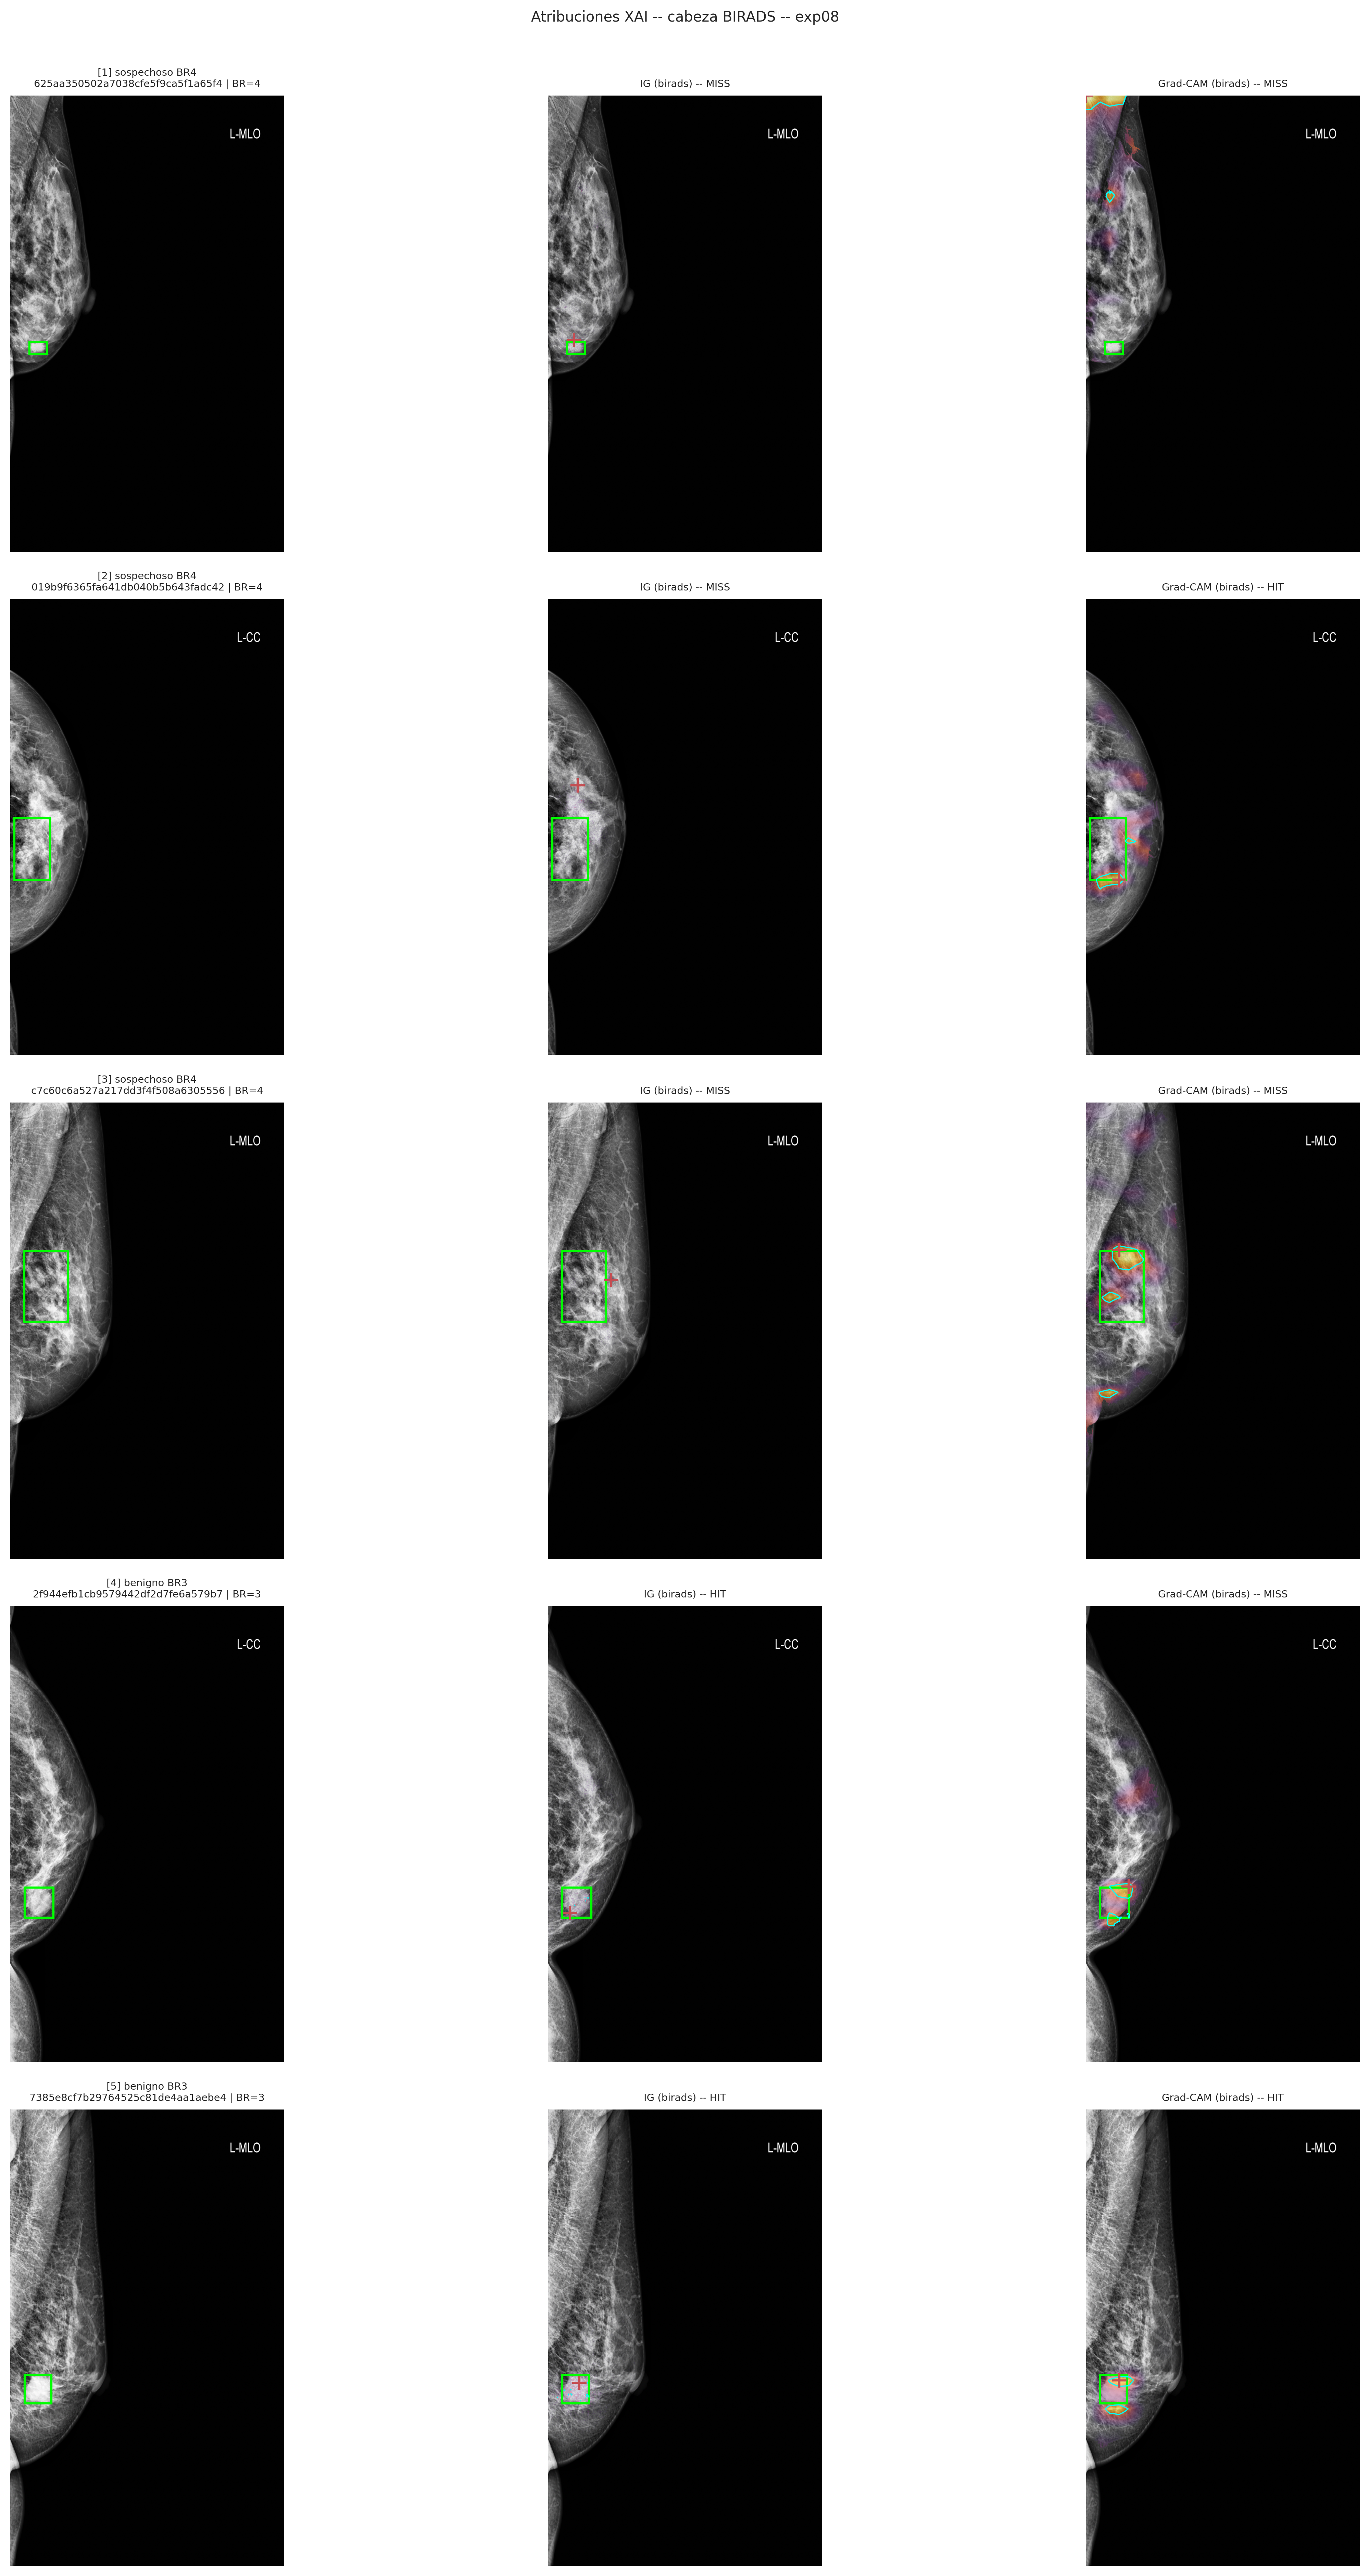

In [6]:
## VISUALIZACION: overlay de IG y Grad-CAM sobre 5 imagenes representativas
## (3 sospechosas BR4-5 y 2 benignas BR1-3).
## figura_grid_seleccion genera el grid N x 3: original | IG | Grad-CAM,
## dibuja cajas GT en verde y marca el pixel de maximo con cruz roja.
## plt.ioff() evita que Jupyter registre la figura internamente durante la llamada:
## la funcion llama plt.close(fig) al terminar; sin ioff(), el backend inline de
## Jupyter intenta mostrar esa figura ya cerrada y produce un canvas en blanco.
from xai.visualizacion_xai import figura_grid_seleccion
from xai.metricas_clasificador import preparar_cajas_test
from xai.atribucion_clasificador import cargar_atribucion
from IPython.display import Image as IPyImage, display

transform = cargar_transform_inferencia()
cajas_viz = preparar_cajas_test()

sosp_ids = (cajas_viz[cajas_viz['finding_birads'].isin([4, 5])]
            .drop_duplicates('image_id')['image_id'].tolist())
beni_ids  = (cajas_viz[cajas_viz['finding_birads'].isin([1, 2, 3])]
             .drop_duplicates('image_id')['image_id'].tolist())

seleccion = []
for img_id in sosp_ids[:3]:
    row = cajas_viz[cajas_viz['image_id'] == img_id].iloc[0]
    seleccion.append({'image_id': img_id, 'image_path': row['image_path'],
                      'cajas_imagen': cajas_viz[cajas_viz['image_id'] == img_id],
                      'label': f'sospechoso BR{int(row["finding_birads"])}'})
for img_id in beni_ids[:2]:
    row = cajas_viz[cajas_viz['image_id'] == img_id].iloc[0]
    seleccion.append({'image_id': img_id, 'image_path': row['image_path'],
                      'cajas_imagen': cajas_viz[cajas_viz['image_id'] == img_id],
                      'label': f'benigno BR{int(row["finding_birads"])}'})

plt.ioff()
ruta_fig = figura_grid_seleccion(
    seleccion, cargar_atribucion, transform, device_str,
    head='birads', nombre='lab_int_overlay_birads'
)
plt.ion()

## Leer los bytes del PNG y pasarlos directamente a IPyImage.
## Usar data= (bytes) en lugar de filename= incrusta la imagen en el .ipynb:
## el output queda guardado en la celda y se muestra aunque el PNG se borre.
with open(ruta_fig, 'rb') as _f:
    _img_bytes = _f.read()

print("Figura guardada en:", ruta_fig)
display(IPyImage(data=_img_bytes, width=900))


<h3>Eje 1 - Fidelidad: Deletion AUC</h3>
<p>Se borran progresivamente los pixeles mas salientes (segun cada mapa) y se mide la caida
del score. Caida rapida (AUC baja) = mapa mas fiel. Se incluye un baseline de <b>orden
aleatorio</b> de pixeles: cualquier metodo util tiene que superarlo.</p>


In [7]:
## DELETION AUC para IG, Grad-CAM y baseline aleatorio, en ambas cabezas.
## evaluar_deletion_auc requiere el modelo, el test_df y una funcion de carga de .npz.
## cargar_atribucion(image_id, head, out_dir) -> dict con claves 'ig', 'gradcam', 'meta'.
from xai.metricas_clasificador import evaluar_deletion_auc
from xai.atribucion_clasificador import cargar_atribucion

print("Calculando Deletion AUC (birads) -- muestra de 50 imagenes...")
df_dauc_birads = evaluar_deletion_auc(
    clasificador, df_test, cargar_atribucion,
    head='birads', device=device_str, n_sample=50,
    include_random_baseline=True,
)
print("Calculando Deletion AUC (density)...")
df_dauc_density = evaluar_deletion_auc(
    clasificador, df_test, cargar_atribucion,
    head='density', device=device_str, n_sample=50,
    include_random_baseline=True,
)

for nombre, df_h in [('BI-RADS', df_dauc_birads), ('Densidad', df_dauc_density)]:
    tabla = (
        df_h.groupby('method')['auc']
        .agg(media='mean', std='std')
        .reset_index()
        .sort_values('media')
    )
    print(f"\nDeletion AUC -- cabeza {nombre} (menor = mas fiel):")
    print(tabla.to_string(index=False))


Calculando Deletion AUC (birads) -- muestra de 50 imagenes...


Deletion AUC (birads): 100%|██████████| 50/50 [02:24<00:00,  2.88s/it]


Calculando Deletion AUC (density)...


Deletion AUC (density): 100%|██████████| 50/50 [01:45<00:00,  2.11s/it]


Deletion AUC -- cabeza BI-RADS (menor = mas fiel):
 method    media      std
 random 0.167880 0.102051
     ig 0.184250 0.107522
gradcam 0.214953 0.111939

Deletion AUC -- cabeza Densidad (menor = mas fiel):
 method    media      std
 random 0.230569 0.136235
     ig 0.233589 0.131940
gradcam 0.271824 0.216588


In [8]:
## Comparacion pareada vs random con IC95 bootstrap (negativo = mejor que random).
## comparar_deletion_auc_vs_random recibe el DataFrame con method='random' incluido.
from xai.metricas_clasificador import comparar_deletion_auc_vs_random

df_dauc_all = pd.concat([df_dauc_birads, df_dauc_density], ignore_index=True)
tabla_pareada = comparar_deletion_auc_vs_random(df_dauc_all, n_bootstrap=2000, seed=SEED)
print("Diferencia pareada (negativo = mejor que random; IC95 sin cruzar 0 = significativo):")
print(tabla_pareada.to_string(index=False))


Diferencia pareada (negativo = mejor que random; IC95 sin cruzar 0 = significativo):
   head  metodo  n_imagenes  delta_medio   ic95_lo  ic95_hi  p_peor_random
 birads      ig          50     0.016369  0.004725 0.028679          0.992
 birads gradcam          50     0.047073  0.018237 0.075223          0.999
density      ig          50     0.003020 -0.005598 0.010481          0.771
density gradcam          50     0.041255 -0.009430 0.095490          0.943


<h3>Eje 2 - Localizacion: Pointing Game estratificado</h3>
<p>El maximo del mapa debe caer dentro de la caja anotada. Se estratifica en sospechoso
(BR4-5) y benigno (BR3). Solo cabeza BI-RADS. Las 187 + 181 = 368 imagenes exceden las 357
unicas porque algunas tienen un hallazgo benigno y uno sospechoso, cayendo en ambos
estratos.</p>


In [9]:
## POINTING GAME estratificado para IG y Grad-CAM (solo cabeza BI-RADS).
## evaluar_pointing_game retorna (image_id, method, hit); la estratificacion
## se hace manualmente uniendo con finding_birads de cajas_df.
from xai.metricas_clasificador import evaluar_pointing_game, preparar_cajas_test

## Cajas escaladas al espacio de entrada del modelo (1520 x 912)
cajas_df = preparar_cajas_test()

print("Calculando Pointing Game (IG y Grad-CAM)...")
df_pg = evaluar_pointing_game(
    cargar_atribucion, cajas_df, head='birads', device=device_str
)

## Estratificacion por finding_birads: sospechoso BR4-5 vs benigno BR1-3
pg_con_birads = df_pg.merge(
    cajas_df[['image_id', 'finding_birads']].drop_duplicates(),
    on='image_id', how='left',
)
estratos = {
    'Sospechoso (BR4-5)': pg_con_birads['finding_birads'].isin([4, 5]),
    'Benigno (BR1-3)':    pg_con_birads['finding_birads'].isin([1, 2, 3]),
}
registros_pg = []
for estrato, mask in estratos.items():
    grp = pg_con_birads[mask]
    for met in ('ig', 'gradcam'):
        sub = grp[grp['method'] == met]
        registros_pg.append({
            'Estrato': estrato, 'Metodo': met,
            'hit_rate': round(float(sub['hit'].mean()), 4) if not sub.empty else float('nan'),
            'n': len(sub),
        })
tabla_pg = pd.DataFrame(registros_pg)
print("Pointing Game -- BI-RADS (hit rate por metodo y estrato):")
print(tabla_pg.to_string(index=False))


Calculando Pointing Game (IG y Grad-CAM)...


Pointing Game: 100%|██████████| 357/357 [00:20<00:00, 17.69it/s]

Pointing Game -- BI-RADS (hit rate por metodo y estrato):
           Estrato  Metodo  hit_rate   n
Sospechoso (BR4-5)      ig    0.5707 205
Sospechoso (BR4-5) gradcam    0.4195 205
   Benigno (BR1-3)      ig    0.3978 181
   Benigno (BR1-3) gradcam    0.2320 181


<h3>Eje 3 - Acuerdo: IoU IG vs Grad-CAM</h3>
<p>Interseccion sobre union de las regiones top-25% de cada mapa. Mide si las dos tecnicas
coinciden. Un IoU bajo significa que son explicaciones distintas, lo que hace el contraste
informativo en lugar de redundante.</p>


In [10]:
## IoU IG vs Grad-CAM (top-25%) en ambas cabezas.
## evaluar_iou_ig_gradcam(attr_load_func, image_ids, top_k, head, test_df)
from xai.metricas_clasificador import evaluar_iou_ig_gradcam

image_ids = df_test['image_id'].tolist()

df_iou_birads = evaluar_iou_ig_gradcam(
    cargar_atribucion, image_ids, top_k=0.25, head='birads', test_df=df_test
)
df_iou_density = evaluar_iou_ig_gradcam(
    cargar_atribucion, image_ids, top_k=0.25, head='density', test_df=df_test
)
print("IoU IG-GradCAM medio BI-RADS  (top-25%):", round(float(df_iou_birads['iou'].mean()), 4))
print("IoU IG-GradCAM medio Densidad (top-25%):", round(float(df_iou_density['iou'].mean()), 4))


IoU IG vs GradCAM: 100%|██████████| 4000/4000 [19:04<00:00,  3.49it/s]

IoU IG-GradCAM medio BI-RADS  (top-25%): 0.197
IoU IG-GradCAM medio Densidad (top-25%): 0.2223


<h1>Punto 4: Discusion (xAI1 vs xAI2)</h1>

<p>Resultados obtenidos sobre el split de test de exp08 (357 imagenes con caja, 452
hallazgos). Estos son los valores que reproducen las celdas anteriores al ejecutarse.</p>

<h3>Fidelidad - Deletion AUC (menor = mas fiel)</h3>
<table>
  <tr><th>Cabeza</th><th>IG</th><th>Grad-CAM</th><th>random</th></tr>
  <tr><td>BI-RADS</td><td>0.1843 (0.108)</td><td>0.2150 (0.112)</td><td><b>0.1679 (0.102)</b></td></tr>
  <tr><td>Densidad</td><td>0.2336 (0.132)</td><td>0.2718 (0.217)</td><td><b>0.2306 (0.136)</b></td></tr>
</table>

<h3>Comparacion pareada vs random (IC95 bootstrap; negativo = mejor que random)</h3>
<table>
  <tr><th>Cabeza</th><th>Metodo</th><th>delta medio</th><th>IC95</th><th>Veredicto</th></tr>
  <tr><td>BI-RADS</td><td>IG</td><td>+0.0164</td><td>[0.0047, 0.0287]</td><td>peor que random (significativo)</td></tr>
  <tr><td>BI-RADS</td><td>Grad-CAM</td><td>+0.0471</td><td>[0.0182, 0.0752]</td><td>peor que random (significativo)</td></tr>
  <tr><td>Densidad</td><td>IG</td><td>+0.0030</td><td>[-0.0056, 0.0105]</td><td>indistinguible del azar</td></tr>
  <tr><td>Densidad</td><td>Grad-CAM</td><td>+0.0413</td><td>[-0.0094, 0.0955]</td><td>indistinguible del azar</td></tr>
</table>

<h3>Localizacion - Pointing Game (hit rate)</h3>
<table>
  <tr><th>Estrato</th><th>IG</th><th>Grad-CAM</th><th>n</th></tr>
  <tr><td>Sospechoso (BR4-5)</td><td><b>0.5187</b></td><td>0.4011</td><td>187</td></tr>
  <tr><td>Benigno (BR3)</td><td>0.3812</td><td>0.2486</td><td>181</td></tr>
</table>

<h3>Acuerdo - IoU IG vs Grad-CAM (top-25%)</h3>
<p>BI-RADS: <b>0.1970</b> &nbsp;|&nbsp; Densidad: <b>0.2223</b></p>

<h3>Lectura</h3>
<ul>
  <li><b>Fidelidad: el hallazgo que pesa.</b> Ni IG ni Grad-CAM superan el baseline
      aleatorio. En BI-RADS ambos son <b>significativamente peores</b> que el azar (el CI
      pareado no cruza 0). Borrar los pixeles "salientes" no derrumba la prediccion mas
      rapido que borrar pixeles al azar: <b>el modelo no concentra su decision en esos
      pixeles</b>.</li>
  <li><b>Localizacion: resultado positivo.</b> IG acierta la lesion 52% en casos sospechosos
      vs 38% en benignos, y supera a Grad-CAM en ambos estratos. Que el hit rate sea mayor en
      sospechosos que en benignos muestra que el mapa <b>no localiza ruido</b>: cuando la
      lesion es de verdad sospechosa, el pico cae sobre ella mas seguido.</li>
  <li><b>Acuerdo: bajo.</b> IoU 0.197 / 0.222 indica que IG y Grad-CAM coinciden poco. No son
      intercambiables; el contraste dice algo real.</li>
  <li><b>IG vs Grad-CAM.</b> IG localiza mejor (Pointing Game superior) y es marginalmente mas
      fiel (Deletion AUC menor), pero <b>ninguno es fiel en terminos absolutos</b>. Grad-CAM,
      mas estable y barato, localiza peor.</li>
</ul>

<h3>Sintesis</h3>
<p>El mapa apunta a la lesion (localizacion parcial correcta) pero la prediccion <b>no
depende de esos pixeles</b> (fidelidad nula frente al azar). Es decir, el clasificador
predice a partir de caracteristicas dispersas de la imagen, no de la lesion anotada. No hay
que confundir "el pico cae en la lesion" con "el modelo usa la lesion".</p>


<h1>Punto 5: Conclusiones</h1>

<ol>
  <li>Se aplicaron dos tecnicas de explicabilidad de familias distintas (Integrated
      Gradients por gradiente, Grad-CAM por activacion) sobre un clasificador mamografico de
      caja negra transferido (exp08), sin reentrenarlo.</li>

  <li>El contraste se sostiene con tres ejes cuantitativos: fidelidad (Deletion AUC con
      baseline aleatorio y CI bootstrap pareado), localizacion (Pointing Game estratificado)
      y acuerdo (IoU). Dos mapas parecidos no prueban correccion; las metricas si.</li>

  <li>Hallazgo central: <b>fidelidad nula</b>. Ni IG ni Grad-CAM superan el azar al borrar
      pixeles; en BI-RADS son significativamente peores. El modelo no apoya su decision en
      los pixeles que los mapas marcan como importantes.</li>

  <li>Matiz que evita una conclusion falsa: <b>la localizacion si funciona</b>. El Pointing
      Game estratifica en la direccion correcta (sospechoso 0.52 &gt; benigno 0.38 en IG). El
      mapa apunta a la lesion aunque el modelo no dependa de ella.</li>

  <li>Comparacion: IG supera a Grad-CAM en localizacion y en fidelidad marginal; el IoU bajo
      (0.197 / 0.222) confirma que no son intercambiables. Limitaciones declaradas: Grad-CAM
      solo observa la rama convolucional; la baseline negra de IG condiciona la atribucion;
      Deletion AUC depende del orden de borrado.</li>

  <li>Conexion con la tesis: la prediccion desde caracteristicas dispersas es coherente con
      el fracaso de generalizacion cross-domain del modelo. La explicabilidad no solo ilustra,
      tambien diagnostica una debilidad real del clasificador.</li>

  <li>El experimento muestra que la oposición entre método agnóstico y método específico es una falsa dualidad cuando lo que se busca es fidelidad. Los métodos agnósticos (LIME, SHAP) perturban por superpíxeles, y en mamografía ese bloque borra la estructura sub-superpíxel (microcalcificaciones y márgenes de masa) que sostiene el diagnóstico; LIME es además inestable entre ejecuciones y KernelSHAP resulta prohibitivo a resolución clínica. Integrated Gradients y Grad-CAM evitan ese cuello de botella porque exp08 satisface sus precondiciones (diferenciabilidad y backbone convolucional): la suposicion se cumple, no se viola, y la atribución es determinista y barata. La agnosticidad no desaparece, se reubica. La métrica que juzga las explicaciones, Deletion AUC, sí es model-agnostic y fue precisamente esa métrica agnóstica la que reveló que ni IG ni Grad-CAM superan el azar. La lección es que el rigor agnóstico pertenece a la vara con que se mide la fidelidad, no necesariamente al explicador, un explicador bien elegido para el modelo, evaluado con una métrica agnóstica es más informativo que un explicador agnóstico forzado sobre una imagen médica.</li>
</ol>


<h1>Sobre la materia</h1>

<p>Considero que la explicabilidad e interpretabilidad deben ser un pilar fundamental en el desarrollo de la inteligencia artificial, cada vez trabajamos con arquitecturas más complejas, poco a poco se pierde visibilidad o transparencia de su funcionamiento, convirtiendo esto en una caja negra, entonces es ahi que entran la explicabilidad e interpretabilidad para ayudar a garantizar que estos sistemas sean seguros, éticos y eficientes.
Tambien seria necesario que se profundice un poco mas en el uso de modelos que sirven para realizar validacion cientifica y de depuracion de los modelos optimizando las arquitectuiras diseñadas y detectando correlaciones reales o de falsas. Otro de los puntos que nos hga enseñado el uso de XAI es sobre el cumplimiento regulatorio del derecho a la explicación sobre los modelos que se desarrollan como caja negra.